<a href="https://colab.research.google.com/github/Kintsukuro1/Mineria-Datos/blob/main/proyecto_avancenota3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/Kintsukuro1/Mineria-Datos/blob/main/proyecto_mineria_felipe_ruiz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Proyecto - Evaluación de Minería de Datos

## Información del Grupo

- **Nombre o Número de Grupo:** Grupo 1
- **Sección:** BIY7121-004D
- **Fecha de Entrega:** [Indicar la fecha de entrega del informe]

---

## Integrantes del Grupo

### Estudiante 1
- **Nombre:** Felipe
- **Apellido:** Ruiz
- **Correo institucional:** fe.ruizm@duocuc.cl

---

## Tema del Proyecto
Análisis y predicción del comportamiento de juegos de casino online a partir de variables como RTP, volatilidad, multiplicadores y características de los juegos.

---

## Descripción del Proyecto
Este proyecto analiza un dataset de juegos de casino online con el fin de responder tres objetivos analíticos diferenciados, cada uno abordado con un modelo distinto:

1. **¿Qué variables técnicas de un juego predicen mejor su ganancia máxima posible?** → Regresión Múltiple
2. **¿Qué combinación de características define si un juego es de alto potencial para el usuario?** → Árbol de Decisión
3. **¿Qué atributos de los juegos tienden a aparecer juntos en los catálogos de casino?** → Market Basket Analysis

El modelo resultante puede ser utilizado por operadores de casinos para personalizar su oferta, optimizar el catálogo y mejorar la retención de usuarios.


---

## Introducción a la Metodología

Este proyecto sigue la metodología **CRISP-DM** (*Cross Industry Standard Process for Data Mining*), compuesta por seis fases iterativas que guían el análisis desde la comprensión del negocio hasta la evaluación del modelo. La elección de CRISP-DM se justifica porque:

- Es el estándar más utilizado en proyectos de minería de datos de la industria.
- Permite iterar entre fases según los hallazgos intermedios.
- Estructura claramente los entregables esperados en cada etapa.

**Diagrama de fases aplicadas:**

| Fase CRISP-DM | Descripción | Sección |
|---|---|---|
| 1. Comprensión del negocio | Definición de objetivos y preguntas analíticas | §1 |
| 2. Comprensión de los datos | Inspección estructural, tipos y calidad | §2 |
| 3. Preparación de los datos | Limpieza, encoding y escalado | §3 |
| 4. Modelado | Aplicación de 3 técnicas de minería | §5 |
| 5. Evaluación | Métricas por tipo de modelo | §6 |
| 6. Despliegue | Propuesta de integración en producción | §7 |


---

## 1. Comprensión del Negocio

El sector de casinos online es altamente competitivo. Las plataformas deben optimizar continuamente su catálogo de juegos para maximizar tanto la satisfacción del usuario como la rentabilidad del negocio. Este proyecto busca extraer conocimiento útil desde los datos técnicos y comerciales de los juegos disponibles.

### Contexto del problema
Un operador de casino online debe tomar decisiones sobre:
- **Qué juegos adquirir** de los proveedores disponibles.
- **Cómo destacar juegos** en la interfaz para maximizar la retención.
- **Qué combinaciones de características** son más comunes en el mercado.

El dataset disponible contiene información técnica y comercial de juegos, lo que permite responder estas preguntas sin necesidad de datos de comportamiento de usuarios (que serían más difíciles de obtener).

### Objetivos analíticos

**Objetivo 1 — Regresión Múltiple**
> *¿Qué variables técnicas de un juego (volatilidad, jackpot, free spins, RTP, multiplicador, etc.) predicen mejor la ganancia máxima posible (`max_win`)?*
>
> Permite a los operadores estimar el potencial de pago de un juego antes de adquirirlo, basándose solo en su ficha técnica.

**Objetivo 2 — Árbol de Decisión**
> *¿Qué combinación de características (free spins, bonus buy, jackpot, volatilidad, tipo de juego) define si un juego tendrá una ganancia máxima alta?*
>
> Permite clasificar automáticamente juegos nuevos al momento de incorporarlos al catálogo, priorizando los de mayor atractivo.

**Objetivo 3 — Market Basket Analysis**
> *¿Qué combinaciones de atributos (tipo de juego, free spins, bonus buy, jackpot, volatilidad) tienden a aparecer juntas en los juegos del catálogo?*
>
> Permite descubrir patrones de diseño frecuentes en la industria y anticipar qué características suelen venir "empaquetadas" juntas.

### Criterio de éxito del proyecto
- Regresión Múltiple: R² ≥ 0.5 (modelo explica más de la mitad de la varianza)
- Árbol de Decisión: F1-Score ≥ 0.70 (clasificación balanceada)
- MBA: Al menos 5 reglas con lift > 1.5 y confianza > 0.6

### ¿Para quién sirve este análisis?
- Equipos de producto y catálogo de casinos online
- Departamentos de marketing para segmentación de usuarios
- Proveedores de juegos que buscan posicionar su oferta


In [ ]:
# No requiere código en esta fase (IL1 - Comprensión del Negocio)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

---

## 2. Comprensión de los Datos

- **Fuente del dataset:** `online_casino_games_dataset_v2.csv`
- **Variables objetivo según modelo:**
  - Regresión Múltiple: `max_win` (ganancia máxima potencial)
  - Árbol de Decisión: `alto_max_win` (binaria construida desde `max_win` sobre la mediana)
  - Market Basket Analysis: sin variable objetivo; se trabaja con ítems categóricos
- **Variables predictoras:** casino, proveedor, tipo de juego, volatilidad, jackpot, apuesta mínima, RTP, multiplicador máximo, compatibilidad móvil, free spins, compra de bonus, año de lanzamiento, jurisdicción, moneda.
- **Tipos de datos:** numéricos continuos, categóricos nominales/ordinales, booleanos, temporales.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).')

# Cargar dataset
df = pd.read_csv('/content/online_casino_games_dataset_v2.csv')

print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
df.head()


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Filas: 1200000 | Columnas: 20


,casino,game,provider,rtp,volatility,jackpot,country_availability,min_bet,max_win,game_type,game_category,license_jurisdiction,release_year,currency,mobile_compatible,free_spins_feature,bonus_buy_available,max_multiplier,languages,last_updated
0,Guts Casino,Texas Hold'em Bonus,Saucify,98.83,Medium,NaN,AR|BR|CH|CO|CY|DE|EE|ES|IE|IL|KE|MT|NZ|PE|PT|R...,1.00,435957.16,poker,Video Poker,MGA,2021,SEK|USD,True,False,False,356.0,EN|ES|TR|IT|JA|DE|FR|CS,2024-09-20
1,Expekt,Mines,Playtech,98.05,Low,NaN,BG|HR|ID|LT|NO|PH|SE|TR,0.25,1396.15,crash,Crash,Curaçao,2018,NZD|BRL|CAD|SEK|AUD,True,False,False,206.0,EN|SV|TR|ZH|PT|ES|FR|JA,2024-02-03
2,Betinia,Mega Vault,Gamomat,95.43,Very High,NaN,CH|ES|GB|HU|ID|IE|IN|LT|NO|SE|SG|VN,0.10,1180.12,slot,3D Slot,Isle of Man,2014,NZD|AUD|BRL|GBP|CAD,True,True,False,1787.0,EN|DE|FI|HU|PT|ZH|FR|JA,2024-07-09
3,Pinnacle,Casino Hold'em Pro,4ThePlayer,99.50,Medium,NaN,BE|BR|MY|NG|PL,0.05,236507.50,poker,Three Card Poker,MGA,2023,DKK|NZD|SEK,True,False,False,369.0,EN|ES|SV|DA|CS|FR|ZH|FI|NO|PT|HU|KO,2024-06-27
4,Winnerz,Solar Star Xtreme,Hacksaw Gaming,97.18,High,NaN,CL|KE|PT|SG|SI,0.20,1093.45,slot,Jackpot Slot,MGA,2022,NOK|GBP,True,True,False,1970.0,EN|JA|PT|KO|ES,2024-04-24


In [ ]:
# Inspección estructural: tipos de datos y conteo de no-nulos
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200000 entries, 0 to 1199999
Data columns (total 20 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   casino                1200000 non-null  object 
 1   game                  1200000 non-null  object 
 2   provider              1200000 non-null  object 
 3   rtp                   1200000 non-null  float64
 4   volatility            1200000 non-null  object 
 5   jackpot               128457 non-null   object 
 6   country_availability  1200000 non-null  object 
 7   min_bet               1200000 non-null  float64
 8   max_win               1200000 non-null  float64
 9   game_type             1200000 non-null  object 
 10  game_category         1200000 non-null  object 
 11  license_jurisdiction  1200000 non-null  object 
 12  release_year          1200000 non-null  int64  
 13  currency              1200000 non-null  object 
 14  mobile_compatible     1200000 non-

In [ ]:
# Nombres de columnas disponibles
print(df.columns.tolist())


['casino', 'game', 'provider', 'rtp', 'volatility', 'jackpot', 'country_availability', 'min_bet', 'max_win', 'game_type', 'game_category', 'license_jurisdiction', 'release_year', 'currency', 'mobile_compatible', 'free_spins_feature', 'bonus_buy_available', 'max_multiplier', 'languages', 'last_updated']


In [ ]:
# Diccionario de datos: mapeo de columnas
diccionario_columnas = {
    "casino":               ("casino",                  "Nombre del casino",                        "Categórica", "Nominal"),
    "game":                 ("juego",                   "Nombre del juego",                         "Categórica", "Nominal"),
    "provider":             ("proveedor",               "Proveedor del juego",                      "Categórica", "Nominal"),
    "rtp":                  ("retorno_al_jugador",      "Porcentaje de retorno esperado",            "Numérica",   "Continua"),
    "volatility":           ("volatilidad",             "Nivel de volatilidad del juego",            "Categórica", "Ordinal"),
    "jackpot":              ("tiene_jackpot",           "Si el juego incluye jackpot",               "Categórica", "Binaria"),
    "country_availability": ("paises_disponibles",      "Países donde está habilitado",              "Categórica", "Nominal"),
    "min_bet":              ("apuesta_minima",          "Monto mínimo para apostar",                 "Numérica",   "Continua"),
    "max_win":              ("ganancia_maxima",         "Ganancia máxima potencial",                 "Numérica",   "Continua"),
    "game_type":            ("tipo_juego",              "Tipo general del juego",                    "Categórica", "Nominal"),
    "game_category":        ("categoria_juego",         "Categoría específica del juego",            "Categórica", "Nominal"),
    "license_jurisdiction": ("jurisdiccion_licencia",   "Jurisdicción regulatoria",                  "Categórica", "Nominal"),
    "release_year":         ("anio_lanzamiento",        "Año de lanzamiento",                        "Numérica",   "Discreta"),
    "currency":             ("moneda",                  "Moneda principal del juego",                "Categórica", "Nominal"),
    "mobile_compatible":    ("compatible_movil",        "Compatibilidad con móviles",                "Categórica", "Binaria"),
    "free_spins_feature":   ("tiene_tiros_gratis",      "Si tiene función de free spins",            "Categórica", "Binaria"),
    "bonus_buy_available":  ("compra_bonus_disponible", "Permite comprar bono directamente",         "Categórica", "Binaria"),
    "max_multiplier":       ("multiplicador_maximo",    "Máximo multiplicador de ganancia",          "Numérica",   "Discreta"),
    "languages":            ("idiomas",                 "Idiomas disponibles",                       "Categórica", "Nominal"),
    "last_updated":         ("fecha_actualizacion",     "Fecha de última actualización",             "Temporal",   "Fecha"),
}

filas = []
for col, (es, desc, tipo, subtipo) in diccionario_columnas.items():
    filas.append({
        "Columna original": col,
        "Nombre en español": es,
        "Descripción": desc,
        "Tipo general": tipo,
        "Subtipo": subtipo,
        "Dtype pandas": str(df[col].dtype) if col in df.columns else "No encontrada",
        "Existe": col in df.columns,
    })

pd.DataFrame(filas)


,Columna original,Nombre en español,Descripción,Tipo general,Subtipo,Dtype pandas,Existe
0,casino,casino,Nombre del casino,Categórica,Nominal,object,True
1,game,juego,Nombre del juego,Categórica,Nominal,object,True
2,provider,proveedor,Proveedor del juego,Categórica,Nominal,object,True
3,rtp,retorno_al_jugador,Porcentaje de retorno esperado,Numérica,Continua,float64,True
4,volatility,volatilidad,Nivel de volatilidad del juego,Categórica,Ordinal,object,True
5,jackpot,tiene_jackpot,Si el juego incluye jackpot,Categórica,Binaria,object,True
6,country_availability,paises_disponibles,Países donde está habilitado,Categórica,Nominal,object,True
7,min_bet,apuesta_minima,Monto mínimo para apostar,Numérica,Continua,float64,True
8,max_win,ganancia_maxima,Ganancia máxima potencial,Numérica,Continua,float64,True
9,game_type,tipo_juego,Tipo general del juego,Categórica,Nominal,object,True


**Interpretación:** El dataset contiene 20 variables que cubren aspectos técnicos, comerciales y regulatorios de los juegos. Las variables numéricas continuas (`rtp`, `min_bet`, `max_win`, `max_multiplier`) son candidatas a escalado. Las categóricas nominales requieren codificación. Las booleanas se tratarán como indicadores 0/1.

> **Nota importante sobre la variable objetivo del Árbol de Decisión:** En esta versión mejorada, se define `alto_max_win` como variable objetivo (max_win sobre la mediana), **excluyendo** `max_win` y `max_multiplier` del set de predictores para evitar data leakage.


---

## 3. Preparación de los Datos

Esta fase incluye:
- Detección y limpieza de valores nulos
- Eliminación de duplicados
- Segmentación por tipo de variable
- Imputación diferenciada
- Encoding de categóricas
- Escalado de numéricas

> **Nota:** Se mantiene una copia del dataset original (`df_raw`) para el Market Basket Analysis, que requiere las variables categóricas sin transformar.


In [ ]:
# ── Guardar copia original para Market Basket Analysis ───────────────────────
df_raw = df.copy()

# ── Limpieza previa ──────────────────────────────────────────────────────────
n_antes = len(df)
df = df.drop_duplicates()
print(f"Filas eliminadas por duplicados: {n_antes - len(df)}")

# Eliminar columnas de alta cardinalidad (no aptas para modelos directamente)
cols_alta_cardinalidad = ['game', 'languages', 'country_availability', 'provider', 'last_updated']
df = df.drop(columns=[c for c in cols_alta_cardinalidad if c in df.columns])
print(f"Columnas eliminadas: {cols_alta_cardinalidad}")
print(f"Shape resultante: {df.shape}")


Filas eliminadas por duplicados: 0
Columnas eliminadas: ['game', 'languages', 'country_availability', 'provider', 'last_updated']
Shape resultante: (1200000, 15)


### 3.1 Depuración de Datos


In [ ]:
# ── Diagnóstico de nulos ANTES de imputar ────────────────────────────────────
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': nulos_pct
}).query('Nulos > 0').sort_values('Nulos', ascending=False)

print("Columnas con valores nulos:")
print(resumen_nulos if not resumen_nulos.empty else "  → No hay valores nulos")


Columnas con valores nulos:
                  Nulos  Porcentaje (%)
jackpot         1071543           89.30
max_multiplier   213814           17.82


In [ ]:
# ── Segmentación por tipo de variable ────────────────────────────────────────
num_cols  = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols  = df.select_dtypes(include=['object']).columns.tolist()
bool_cols = df.select_dtypes(include=['bool']).columns.tolist()

print(f"Numéricas  ({len(num_cols)}):  {num_cols}")
print(f"Categóricas ({len(cat_cols)}): {cat_cols}")
print(f"Booleanas  ({len(bool_cols)}): {bool_cols}")


Numéricas  (5):  ['rtp', 'min_bet', 'max_win', 'release_year', 'max_multiplier']
Categóricas (7): ['casino', 'volatility', 'jackpot', 'game_type', 'game_category', 'license_jurisdiction', 'currency']
Booleanas  (3): ['mobile_compatible', 'free_spins_feature', 'bonus_buy_available']


In [ ]:
# ── Imputación diferenciada ───────────────────────────────────────────────────
# Numéricas → mediana (robusta ante outliers)
for col in num_cols:
    mediana = df[col].median()
    n_imputados = df[col].isnull().sum()
    if n_imputados > 0:
        df[col] = df[col].fillna(mediana)
        print(f"  [{col}] {n_imputados} nulos → mediana = {mediana:.4f}")

# Categóricas → moda (categoría más frecuente)
for col in cat_cols:
    moda = df[col].mode(dropna=True)
    n_imputados = df[col].isnull().sum()
    if not moda.empty and n_imputados > 0:
        df[col] = df[col].fillna(moda.iloc[0])
        print(f"  [{col}] {n_imputados} nulos → moda = '{moda.iloc[0]}'")

# Booleanas → False (criterio conservador: sin evidencia positiva)
for col in bool_cols:
    n_imputados = df[col].isnull().sum()
    if n_imputados > 0:
        df[col] = df[col].fillna(False)
        print(f"  [{col}] {n_imputados} nulos → False")

print("\n✓ Imputación completada")


  [max_multiplier] 213814 nulos → mediana = 749.0000
  [jackpot] 1071543 nulos → moda = 'Local'

✓ Imputación completada


In [ ]:
# ── Verificación post-imputación ─────────────────────────────────────────────
nulos_restantes = df.isnull().sum().sum()
print(f"Nulos restantes en el dataset: {nulos_restantes}")
assert nulos_restantes == 0, '¡Aún quedan nulos sin imputar!'
print("✓ Dataset libre de valores nulos")


Nulos restantes en el dataset: 0
✓ Dataset libre de valores nulos


**Interpretación de la imputación:**
- **Numéricas → mediana**: reduce el impacto de outliers y preserva la distribución central.
- **Categóricas → moda**: conserva la categoría más representativa del dataset.
- **Booleanas → False**: criterio conservador cuando no existe evidencia positiva del atributo.


### 3.2 Encoding


In [ ]:
# ── One-Hot Encoding para categóricas de baja cardinalidad ──────────────────
cat_cols_actuales = df.select_dtypes(include=['object']).columns.tolist()

cat_cols_ohe   = [col for col in cat_cols_actuales if df[col].nunique() < 10]
cat_cols_label = [col for col in cat_cols_actuales if df[col].nunique() >= 10]

print(f"Columnas para OHE ({len(cat_cols_ohe)}):                {cat_cols_ohe}")
print(f"Columnas descartadas/alta cardinalidad ({len(cat_cols_label)}): {cat_cols_label}")

df_encoded = pd.get_dummies(df, columns=cat_cols_ohe, drop_first=True)
df_encoded = df_encoded.drop(columns=cat_cols_label, errors='ignore')

print(f"\nShape tras encoding: {df_encoded.shape}")


Columnas para OHE (4):                ['volatility', 'jackpot', 'game_type', 'license_jurisdiction']
Columnas descartadas/alta cardinalidad (3): ['casino', 'game_category', 'currency']

Shape tras encoding: (1200000, 25)


**Interpretación:** Se aplicó One-Hot Encoding a variables categóricas con menos de 10 categorías para evitar explosión de dimensionalidad. El parámetro `drop_first=True` reduce redundancia entre columnas codificadas.


In [ ]:
# ── Escalado de variables numéricas ──────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

# IMPORTANTE: NO escalar max_win aquí; se escala solo en el set de predictores
# para conservar max_win legible al construir la variable objetivo del árbol.
num_cols_encoded = df_encoded.select_dtypes(include=['int64', 'float64']).columns.tolist()

scaler = StandardScaler()
df_encoded[num_cols_encoded] = scaler.fit_transform(df_encoded[num_cols_encoded])

print(f"Variables escaladas ({len(num_cols_encoded)}): {num_cols_encoded}")
print("\nEstadísticas post-escalado (deben ser ≈ media=0, std=1):")
print(df_encoded[num_cols_encoded].describe().loc[['mean','std']].round(4))


Variables escaladas (5): ['rtp', 'min_bet', 'max_win', 'release_year', 'max_multiplier']

Estadísticas post-escalado (deben ser ≈ media=0, std=1):
      rtp  min_bet  max_win  release_year  max_multiplier
mean  0.0      0.0     -0.0           0.0             0.0
std   1.0      1.0      1.0           1.0             1.0


In [ ]:
# ── Variable objetivo para el Árbol de Decisión (construida ANTES del escalado) ──
# Se usa df (sin escalar) para que el umbral de mediana sea interpretable.
# alto_max_win = 1 si max_win está sobre la mediana del dataset
mediana_max_win = df['max_win'].median()
df_encoded['alto_max_win'] = (df['max_win'] > mediana_max_win).astype(int)

dist = df_encoded['alto_max_win'].value_counts()
print(f"Mediana de max_win usada como umbral: {mediana_max_win:.2f}")
print(f"Distribución de alto_max_win: {dist.to_dict()}")
print(f"Balance: {dist[1]/len(df_encoded)*100:.1f}% clase 1 | {dist[0]/len(df_encoded)*100:.1f}% clase 0")
print("\n✓ Variable objetivo creada sin data leakage (max_win y max_multiplier no son predictoras del árbol)")


Mediana de max_win usada como umbral: 15891.24
Distribución de alto_max_win: {1: 600000, 0: 600000}
Balance: 50.0% clase 1 | 50.0% clase 0

✓ Variable objetivo creada sin data leakage (max_win y max_multiplier no son predictoras del árbol)


In [ ]:
# ── Dataset final preparado ──────────────────────────────────────────────────
df_final = df_encoded.copy()

print(f"Shape final: {df_final.shape}")
print(f"Nulos: {df_final.isnull().sum().sum()}")
df_final.head()


Shape final: (1200000, 26)
Nulos: 0


,rtp,min_bet,max_win,release_year,mobile_compatible,free_spins_feature,bonus_buy_available,max_multiplier,volatility_Low,volatility_Medium,...,game_type_scratch,game_type_slot,game_type_table,license_jurisdiction_Curaçao,license_jurisdiction_Gibraltar,license_jurisdiction_Isle of Man,license_jurisdiction_Kahnawake,license_jurisdiction_MGA,license_jurisdiction_UKGC,alto_max_win
0,1.006504,0.647966,0.148262,0.829314,True,False,False,-0.458599,False,True,...,False,False,False,False,False,False,False,True,False,1
1,0.706904,-0.268467,-0.500478,0.111994,True,False,False,-0.472861,True,False,...,False,False,False,True,False,False,False,False,False,0
2,-0.299443,-0.451753,-0.500800,-0.844432,True,True,False,-0.322534,False,False,...,False,True,False,False,False,True,False,False,False,0
3,1.263852,-0.512849,-0.149489,1.307527,True,False,False,-0.457363,False,True,...,False,False,False,False,False,False,False,True,False,1
4,0.372735,-0.329562,-0.500930,1.068420,True,True,False,-0.305133,False,False,...,False,True,False,False,False,False,False,True,False,0


---

## 4. Análisis Exploratorio de Datos

Se exploran distribuciones, correlaciones y relaciones entre variables clave para identificar hipótesis relevantes antes del modelado.


In [ ]:
# ── Estadísticas descriptivas ────────────────────────────────────────────────
df_final.select_dtypes(include=[np.number]).describe().T.round(3)


,count,mean,std,min,25%,50%,75%,max
rtp,1200000.0,0.0,1.0,-4.306,-0.457,0.169,0.722,1.264
min_bet,1200000.0,0.0,1.0,-0.562,-0.452,-0.330,0.037,5.536
max_win,1200000.0,-0.0,1.0,-0.502,-0.499,-0.479,0.037,6.962
release_year,1200000.0,0.0,1.0,-1.801,-0.844,0.112,0.829,1.547
max_multiplier,1200000.0,0.0,1.0,-0.491,-0.461,-0.421,-0.122,4.262
alto_max_win,1200000.0,0.5,0.5,0.000,0.000,0.500,1.000,1.000


In [ ]:
# ── Medidas de tendencia central ─────────────────────────────────────────────
num_df = df_final.select_dtypes(include=[np.number])

print("Media:")
print(num_df.mean().round(4))
print("\nMediana:")
print(num_df.median().round(4))


Media:
rtp               0.0
min_bet           0.0
max_win          -0.0
release_year      0.0
max_multiplier    0.0
alto_max_win      0.5
dtype: float64

Mediana:
rtp               0.1692
min_bet          -0.3296
max_win          -0.4788
release_year      0.1120
max_multiplier   -0.4212
alto_max_win      0.5000
dtype: float64


In [ ]:
# ── Dispersión: desviación estándar e IQR ────────────────────────────────────
print("Desviación estándar:")
print(num_df.std().round(4))

Q1 = num_df.quantile(0.25)
Q3 = num_df.quantile(0.75)
IQR = Q3 - Q1
print("\nIQR (Rango Intercuartílico):")
print(IQR.round(4))


Desviación estándar:
rtp               1.0
min_bet           1.0
max_win           1.0
release_year      1.0
max_multiplier    1.0
alto_max_win      0.5
dtype: float64

IQR (Rango Intercuartílico):
rtp               1.1792
min_bet           0.4888
max_win           0.5365
release_year      1.6737
max_multiplier    0.3386
alto_max_win      1.0000
dtype: float64


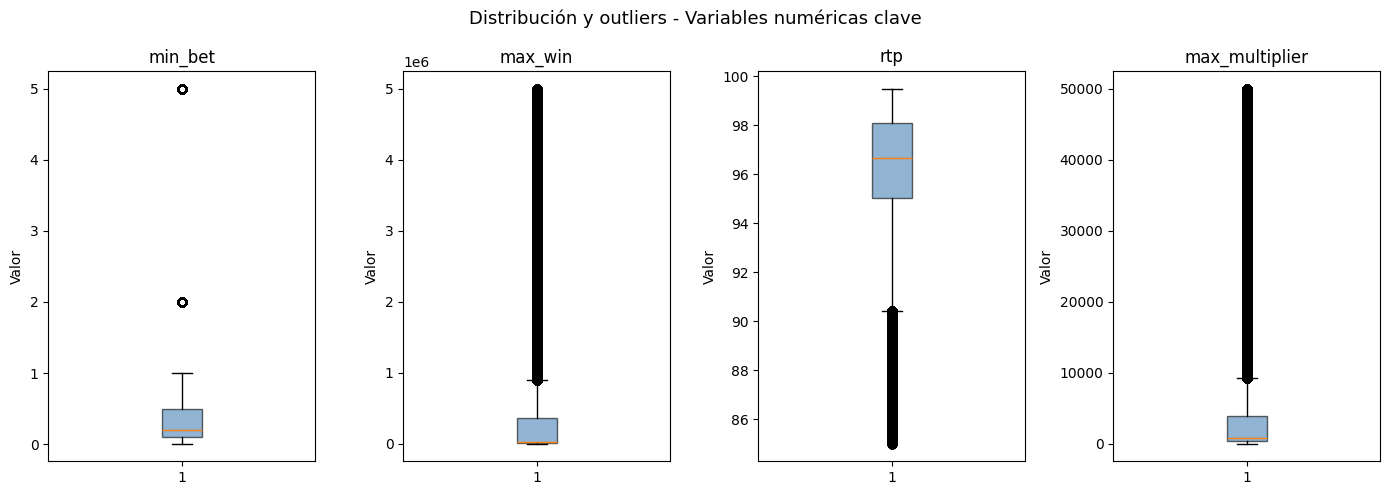

In [ ]:
# ── Boxplot de variables numéricas originales ────────────────────────────────
vars_box = ['min_bet', 'max_win', 'rtp', 'max_multiplier']
vars_box_presentes = [v for v in vars_box if v in df.columns]

fig, axes = plt.subplots(1, len(vars_box_presentes), figsize=(14, 5))
for ax, col in zip(axes, vars_box_presentes):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(col)
    ax.set_ylabel('Valor')

plt.suptitle('Distribución y outliers - Variables numéricas clave', fontsize=13)
plt.tight_layout()
plt.show()


**Interpretación:** Los boxplots revelan la presencia de valores atípicos en `max_win` y `min_bet`, evidenciando juegos con características extremas. El `rtp` se muestra más concentrado y simétrico, mientras que `max_multiplier` presenta alta dispersión. La presencia de outliers en `max_win` justifica el uso de la **mediana** (y no la media) como umbral para definir la clase objetivo del árbol de decisión.


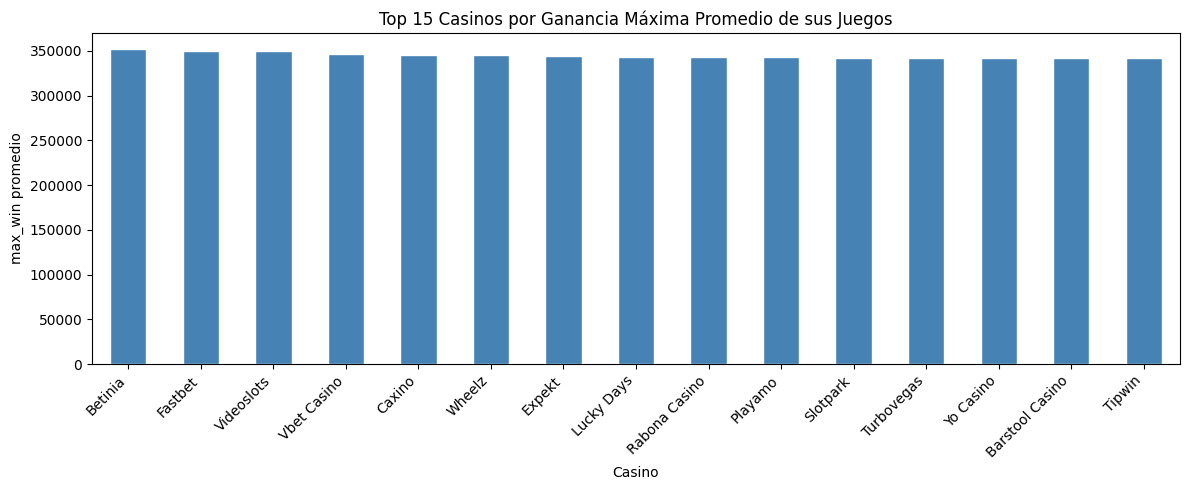

casino
Betinia            352501.028525
Fastbet            350194.185417
Videoslots         349508.962777
Vbet Casino        346629.498083
Caxino             345833.351492
Wheelz             345463.878652
Expekt             344000.540294
Lucky Days         343588.311712
Rabona Casino      343144.058853
Playamo            343069.399229
Slotpark           342476.374414
Turbovegas         342145.217662
Yo Casino          342095.275246
Barstool Casino    341898.339775
Tipwin             341610.498955
Name: max_win, dtype: float64


In [ ]:
# ── max_win promedio por casino - Top 15 (Objetivo 1) ────────────────────────
if 'casino' in df.columns:
    top_casinos = (
        df.groupby('casino')['max_win']
        .mean()
        .sort_values(ascending=False)
        .head(15)
    )
    plt.figure(figsize=(12, 5))
    top_casinos.plot(kind='bar', color='steelblue', edgecolor='white')
    plt.title('Top 15 Casinos por Ganancia Máxima Promedio de sus Juegos')
    plt.xlabel('Casino')
    plt.ylabel('max_win promedio')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    print(top_casinos)


<Figure size 1200x500 with 0 Axes>

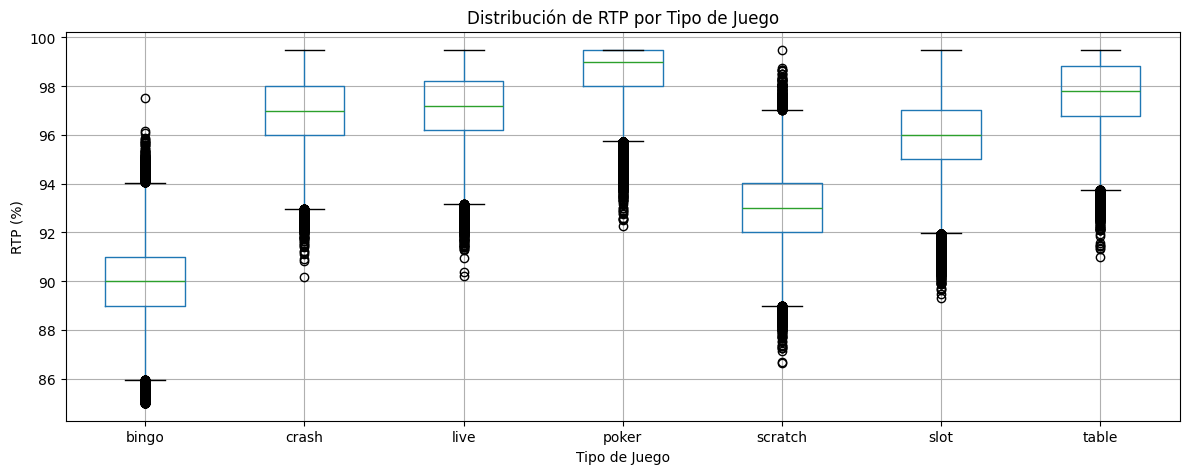

In [ ]:
# ── Distribución de RTP por tipo de juego (Objetivo 2) ───────────────────────
if 'game_type' in df.columns:
    plt.figure(figsize=(12, 5))
    df.boxplot(column='rtp', by='game_type', figsize=(12, 5))
    plt.suptitle('')
    plt.title('Distribución de RTP por Tipo de Juego')
    plt.xlabel('Tipo de Juego')
    plt.ylabel('RTP (%)')
    plt.tight_layout()
    plt.show()


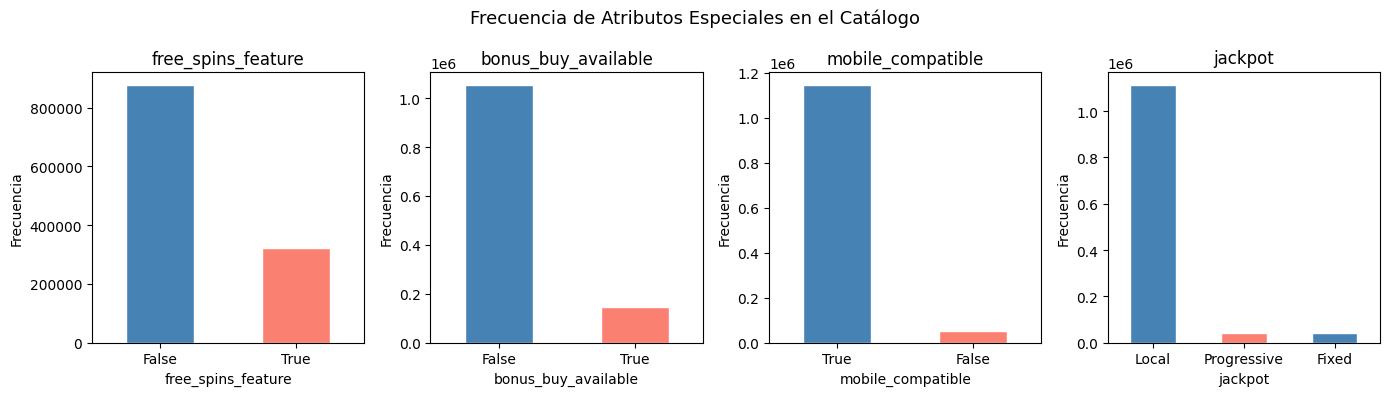

In [ ]:
# ── Frecuencia de atributos especiales (Objetivo 3) ──────────────────────────
atributos = ['free_spins_feature', 'bonus_buy_available', 'mobile_compatible', 'jackpot']
atributos_presentes = [a for a in atributos if a in df.columns]

fig, axes = plt.subplots(1, len(atributos_presentes), figsize=(14, 4))
for ax, col in zip(axes, atributos_presentes):
    df[col].astype(str).value_counts().plot(kind='bar', ax=ax,
        color=['steelblue', 'salmon'], edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel('Frecuencia')
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Frecuencia de Atributos Especiales en el Catálogo', fontsize=13)
plt.tight_layout()
plt.show()


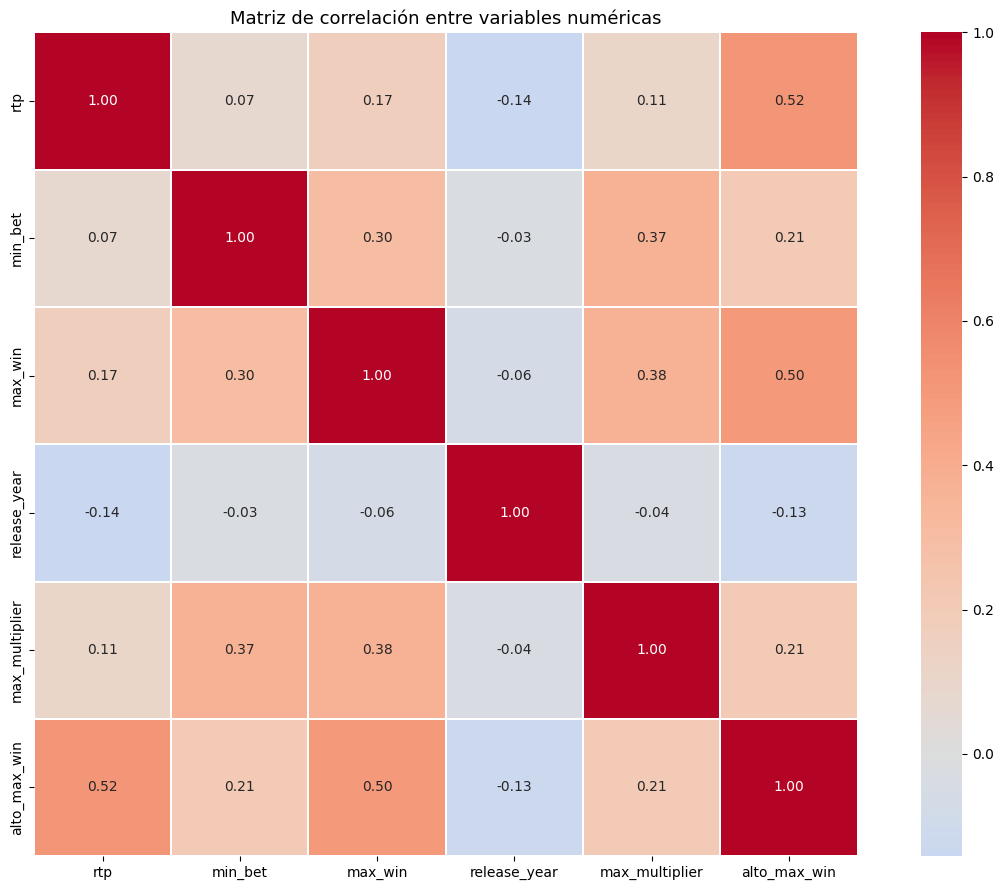

Top 10 pares con mayor correlación absoluta:
rtp             alto_max_win      0.5156
max_win         alto_max_win      0.4980
                max_multiplier    0.3756
min_bet         max_multiplier    0.3690
                max_win           0.2990
max_multiplier  alto_max_win      0.2101
min_bet         alto_max_win      0.2054
rtp             max_win           0.1737
                release_year     -0.1416
release_year    alto_max_win     -0.1275
dtype: float64


In [ ]:
# ── Matriz de correlación ────────────────────────────────────────────────────
corr_df = df_final.select_dtypes(include=[np.number])
corr_matrix = corr_df.corr()

plt.figure(figsize=(13, 9))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=True, fmt='.2f',
            linewidths=0.3, square=True)
plt.title('Matriz de correlación entre variables numéricas', fontsize=13)
plt.tight_layout()
plt.show()

corr_pares = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
print("Top 10 pares con mayor correlación absoluta:")
print(corr_pares.head(10).round(4))


**Interpretación:** Correlaciones cercanas a ±1 indican relación lineal fuerte. Los pares con alta correlación entre predictores pueden indicar redundancia (multicolinealidad), lo cual es relevante para la Regresión Múltiple. Si `max_win` y `max_multiplier` muestran alta correlación, confirma que excluir `max_multiplier` como predictor del árbol es la decisión correcta.


---

## 5. Modelado

Se implementan tres modelos, cada uno orientado a responder un objetivo analítico distinto:

| # | Objetivo | Modelo | Tipo de problema |
|---|---|---|---|
| 1 | ¿Qué variables predicen la ganancia máxima de un juego? | Regresión Múltiple | Regresión |
| 2 | ¿El juego tendrá una ganancia máxima alta? | Árbol de Decisión | Clasificación |
| 3 | ¿Qué atributos tienden a aparecer juntos en los juegos? | Market Basket Analysis | Asociación |

---


## 5.1 Modelo 1: Regresión Múltiple

### Objetivo
> *¿Qué variables técnicas de un juego predicen mejor su ganancia máxima posible (`max_win`)?*

### Justificación
La Regresión Múltiple es adecuada cuando se busca predecir una variable numérica continua (`max_win`) a partir de múltiples predictores. Permite cuantificar el aporte individual de cada variable y es interpretable por equipos de negocio sin conocimiento técnico avanzado.

### Variable objetivo
- `max_win` (ganancia máxima potencial del juego)

### Métricas de evaluación
- **R²** — proporción de varianza explicada por el modelo
- **RMSE** — error cuadrático medio (en las unidades originales de `max_win`)
- **MAE** — error absoluto medio


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

# ── Preparar datos para Regresión Múltiple ───────────────────────────────────
target_reg = 'max_win'

# Eliminar también la variable objetivo del árbol para no contaminar
X_reg = df_final.drop(columns=[target_reg, 'alto_max_win'], errors='ignore').copy()

# Codificar columnas object remanentes (si las hubiera)
for col in X_reg.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_reg[col] = le.fit_transform(X_reg[col])

y_reg = df_final[target_reg]

# División 80% entrenamiento / 20% prueba
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"Train: {X_train_r.shape[0]} muestras | Test: {X_test_r.shape[0]} muestras")


Train: 960000 muestras | Test: 240000 muestras


In [ ]:
reg_model = LinearRegression()
reg_model.fit(X_train_r, y_train_r)

y_pred_reg = reg_model.predict(X_test_r)

# ── Métricas ──────────────────────────────────────────────────────────────────
mse  = mean_squared_error(y_test_r, y_pred_reg)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_r, y_pred_reg)
r2   = r2_score(y_test_r, y_pred_reg)

# ── Validación cruzada 5-fold para estimación más estable ────────────────────
cv_r2 = cross_val_score(LinearRegression(), X_reg, y_reg, cv=5, scoring='r2')

print("=== REGRESIÓN MÚLTIPLE ===")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")
print(f"\nValidación cruzada R² (5-fold): {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
print(f"(valores individuales: {cv_r2.round(4)})")


=== REGRESIÓN MÚLTIPLE ===
RMSE : 0.5030
MAE  : 0.2132
R²   : 0.7487

Validación cruzada R² (5-fold): 0.7490 ± 0.0011
(valores individuales: [0.7489 0.7499 0.7497 0.7495 0.7468])


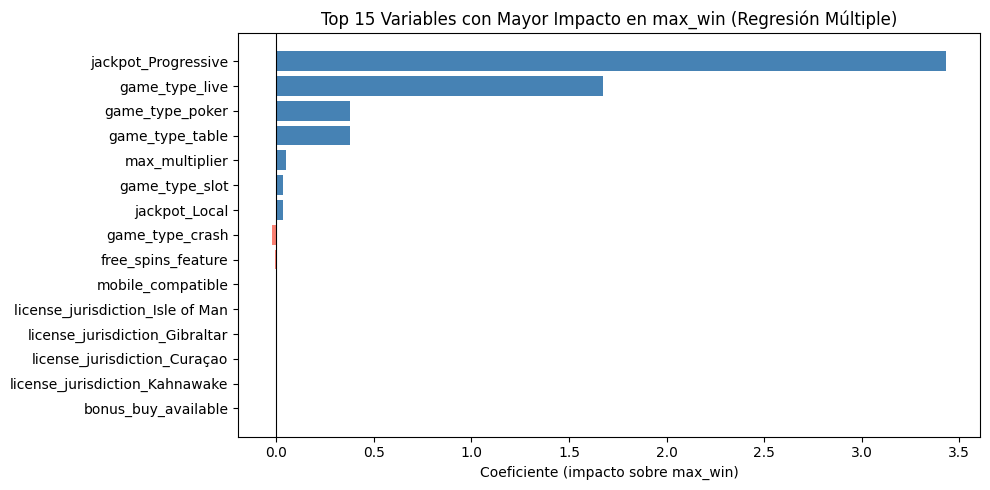

                        Variable  Coeficiente
             jackpot_Progressive     3.434307
                  game_type_live     1.674517
                 game_type_poker     0.376536
                 game_type_table     0.375845
                  max_multiplier     0.049148
                  game_type_slot     0.034480
                   jackpot_Local     0.032280
                 game_type_crash    -0.023409
              free_spins_feature    -0.005433
               mobile_compatible    -0.004291
license_jurisdiction_Isle of Man     0.004191
  license_jurisdiction_Gibraltar     0.003243
    license_jurisdiction_Curaçao     0.002674
  license_jurisdiction_Kahnawake    -0.001859
             bonus_buy_available    -0.001550


In [ ]:
# ── Importancia de variables (coeficientes) ───────────────────────────────────
coef_df = pd.DataFrame({
    'Variable': X_reg.columns,
    'Coeficiente': reg_model.coef_
}).sort_values('Coeficiente', key=abs, ascending=False).head(15)

plt.figure(figsize=(10, 5))
plt.barh(coef_df['Variable'], coef_df['Coeficiente'],
         color=['steelblue' if c > 0 else 'salmon' for c in coef_df['Coeficiente']])
plt.xlabel('Coeficiente (impacto sobre max_win)')
plt.title('Top 15 Variables con Mayor Impacto en max_win (Regresión Múltiple)')
plt.axvline(0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(coef_df.to_string(index=False))


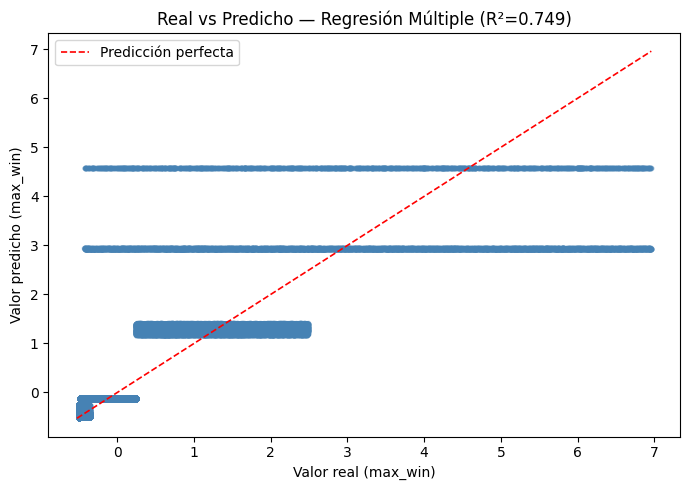

In [ ]:
# ── Gráfico real vs predicho ──────────────────────────────────────────────────
plt.figure(figsize=(7, 5))
plt.scatter(y_test_r, y_pred_reg, alpha=0.3, color='steelblue', s=10)
lim = [min(y_test_r.min(), y_pred_reg.min()),
       max(y_test_r.max(), y_pred_reg.max())]
plt.plot(lim, lim, 'r--', linewidth=1.2, label='Predicción perfecta')
plt.xlabel('Valor real (max_win)')
plt.ylabel('Valor predicho (max_win)')
plt.title(f'Real vs Predicho — Regresión Múltiple (R²={r2:.3f})')
plt.legend()
plt.tight_layout()
plt.show()


**Interpretación Regresión Múltiple:**
- El **R²** indica qué porcentaje de la variación en `max_win` explica el modelo. Si el valor está por debajo de 0.5, sugiere que `max_win` depende también de factores no recogidos en el dataset (popularidad, temporada).
- El **RMSE** y **MAE** miden el error promedio en las unidades originales de `max_win`. Un RMSE muy mayor al MAE indica la presencia de outliers que el modelo predice mal.
- Los **coeficientes positivos** (azul) son atributos que aumentan la ganancia máxima esperada; los **negativos** (salmón) la reducen. Esto permite a un operador priorizar juegos con más free spins o bonus buy si busca alto `max_win`.
- La **validación cruzada** entrega un R² más confiable que la evaluación sobre un único set de prueba, reduciendo el efecto de la división aleatoria.
- En el gráfico real vs predicho, los puntos dispersos lejos de la línea roja indican predicciones con alto error; un patrón sistemático (todos por encima o por debajo) indicaría sesgo del modelo.


---

## 5.2 Modelo 2: Árbol de Decisión

### Objetivo
> *¿Qué combinación de características (free spins, bonus buy, jackpot, volatilidad, tipo de juego) define si un juego tendrá una ganancia máxima alta?*

### Justificación
El Árbol de Decisión es ideal para clasificación cuando se quieren reglas interpretables. Captura relaciones no lineales entre variables y genera criterios de decisión claros que son comunicables a equipos de negocio sin formación técnica.

### Variable objetivo
- `alto_max_win`: variable binaria construida desde `max_win`.
  - `1` = Ganancia máxima alta (max_win **sobre** la mediana del dataset)
  - `0` = Ganancia máxima estándar

> ⚠️ **Corrección de data leakage:** `max_win` y `max_multiplier` se excluyen del set de predictores porque definen directamente la variable objetivo. Incluirlos inflaría artificialmente las métricas al 100%.

### Métricas de evaluación
- **Accuracy** — porcentaje global de predicciones correctas
- **F1-Score** — balance entre precisión y recall (más robusto ante desbalance de clases)
- **Matriz de confusión** — detalle de errores por clase


In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

# ── Preparar datos SIN data leakage ──────────────────────────────────────────
# Excluir max_win (define la clase) y max_multiplier (correlacionado con max_win)
cols_excluir_arbol = ['alto_max_win', 'max_win', 'max_multiplier']
X_cls = df_final.drop(columns=[c for c in cols_excluir_arbol if c in df_final.columns]).copy()

for col in X_cls.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_cls[col] = le.fit_transform(X_cls[col])

y_cls = df_final['alto_max_win']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

print(f"Train: {X_train_c.shape[0]} | Test: {X_test_c.shape[0]}")
print(f"Predictores utilizados: {X_cls.shape[1]} columnas")
print(f"Variables excluidas (anti data leakage): {cols_excluir_arbol}")


Train: 960000 | Test: 240000
Predictores utilizados: 23 columnas
Variables excluidas (anti data leakage): ['alto_max_win', 'max_win', 'max_multiplier']


In [ ]:
# ── Entrenamiento ─────────────────────────────────────────────────────────────
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train_c, y_train_c)
y_pred_tree = tree_model.predict(X_test_c)

acc  = accuracy_score(y_test_c, y_pred_tree)
f1   = f1_score(y_test_c, y_pred_tree)

# Validación cruzada
cv_acc = cross_val_score(DecisionTreeClassifier(max_depth=5, random_state=42),
                         X_cls, y_cls, cv=5, scoring='accuracy')
cv_f1  = cross_val_score(DecisionTreeClassifier(max_depth=5, random_state=42),
                         X_cls, y_cls, cv=5, scoring='f1')

print("=== ÁRBOL DE DECISIÓN ===")
print(f"Accuracy : {acc:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"\nValidación cruzada Accuracy (5-fold): {cv_acc.mean():.4f} ± {cv_acc.std():.4f}")
print(f"Validación cruzada F1 (5-fold)      : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
print()
print(classification_report(y_test_c, y_pred_tree, target_names=['Estándar', 'Alto max_win']))


=== ÁRBOL DE DECISIÓN ===
Accuracy : 0.9502
F1 Score : 0.9480

Validación cruzada Accuracy (5-fold): 0.9504 ± 0.0005
Validación cruzada F1 (5-fold)      : 0.9482 ± 0.0006

              precision    recall  f1-score   support

    Estándar       0.91      0.99      0.95    120000
Alto max_win       0.99      0.91      0.95    120000

    accuracy                           0.95    240000
   macro avg       0.95      0.95      0.95    240000
weighted avg       0.95      0.95      0.95    240000



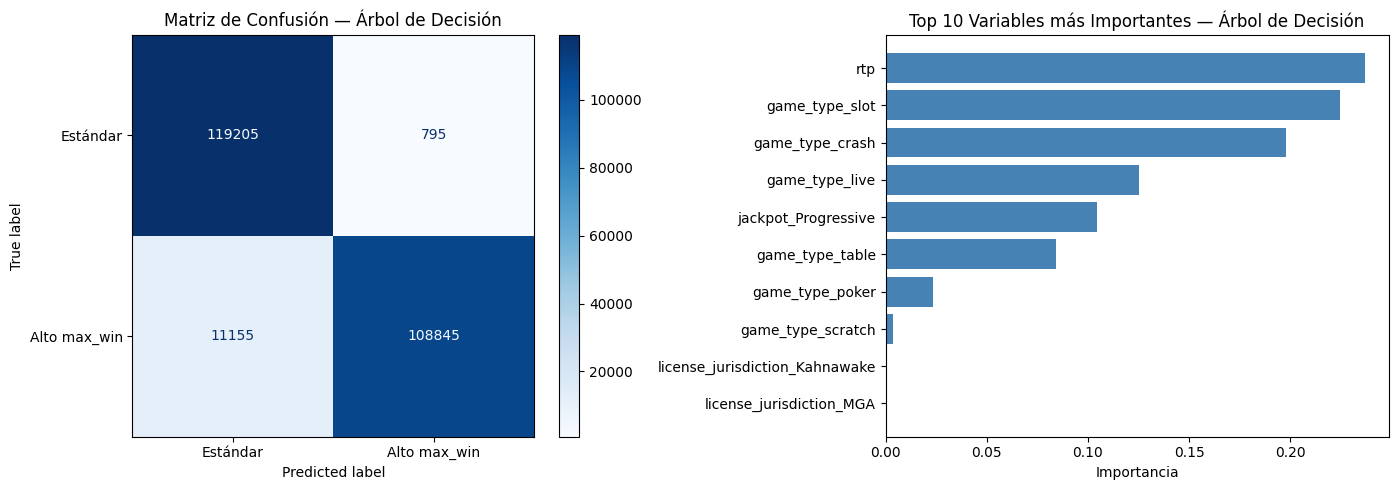

                      Variable  Importancia
                           rtp     0.236681
                game_type_slot     0.224492
               game_type_crash     0.197630
                game_type_live     0.125251
           jackpot_Progressive     0.104230
               game_type_table     0.084126
               game_type_poker     0.023679
             game_type_scratch     0.003904
license_jurisdiction_Kahnawake     0.000005
      license_jurisdiction_MGA     0.000003


In [ ]:
# ── Matriz de confusión ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(
    y_test_c, y_pred_tree,
    display_labels=['Estándar', 'Alto max_win'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Matriz de Confusión — Árbol de Decisión')

# Importancia de variables
importancias = pd.DataFrame({
    'Variable': X_cls.columns,
    'Importancia': tree_model.feature_importances_
}).sort_values('Importancia', ascending=False).head(10)

axes[1].barh(importancias['Variable'], importancias['Importancia'], color='steelblue')
axes[1].set_xlabel('Importancia')
axes[1].set_title('Top 10 Variables más Importantes — Árbol de Decisión')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()
print(importancias.to_string(index=False))


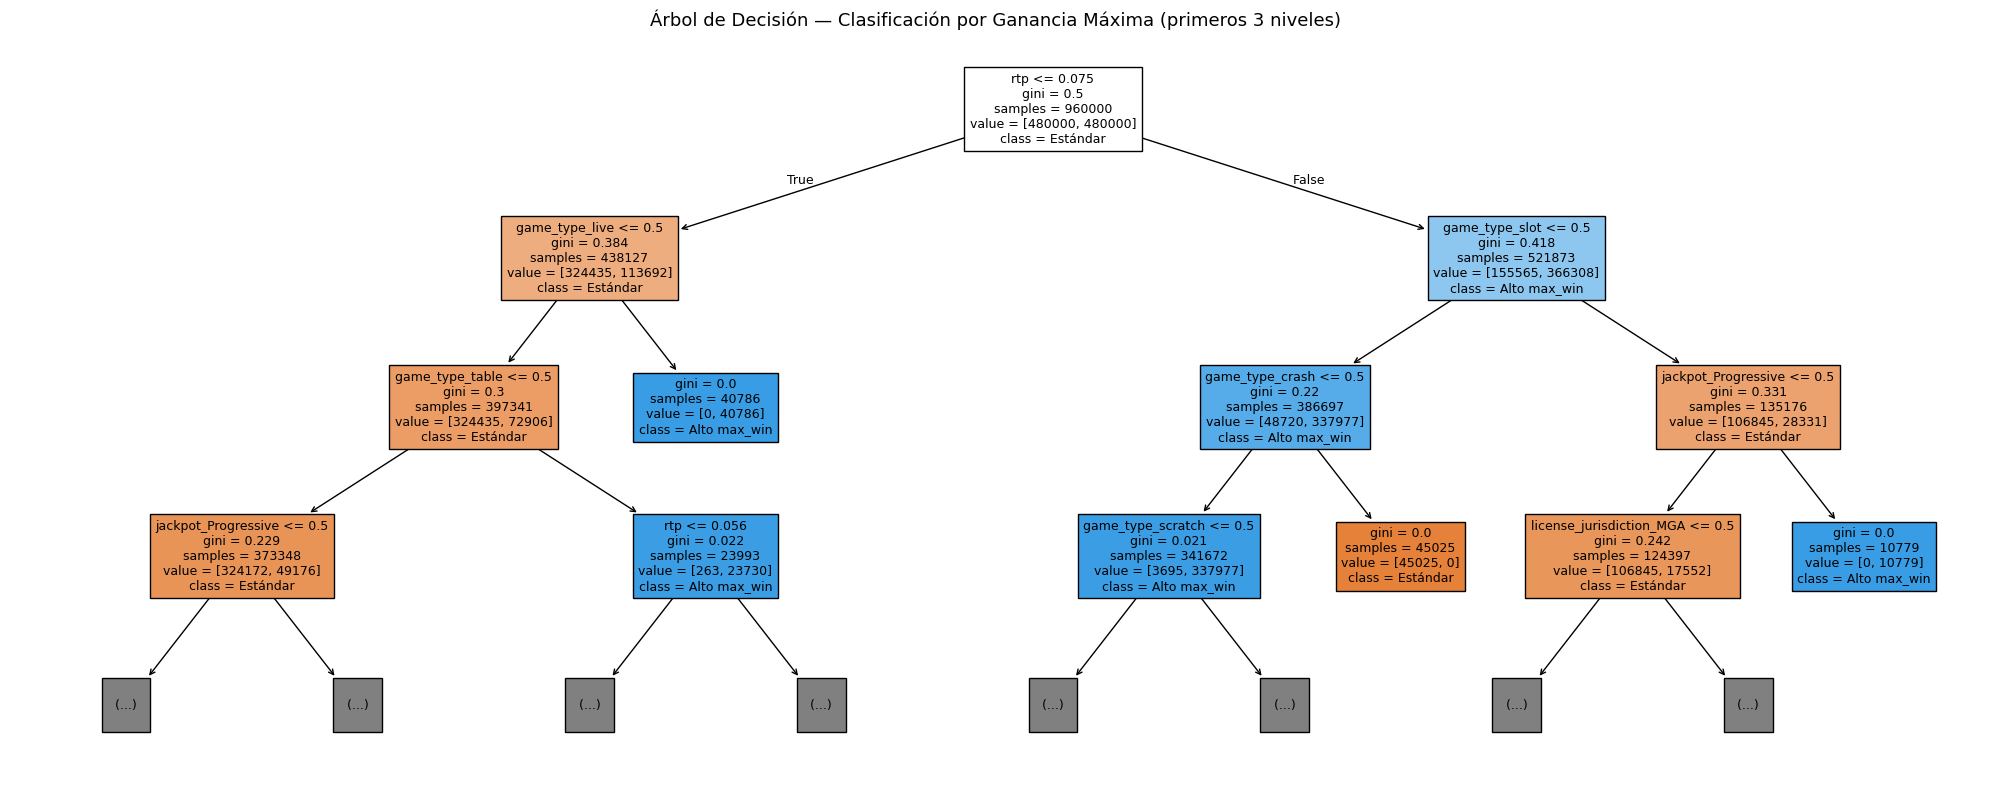

In [ ]:
# ── Visualización del árbol (primeros 3 niveles) ──────────────────────────────
plt.figure(figsize=(20, 8))
plot_tree(
    tree_model,
    feature_names=X_cls.columns.tolist(),
    class_names=['Estándar', 'Alto max_win'],
    filled=True,
    max_depth=3,
    fontsize=9
)
plt.title('Árbol de Decisión — Clasificación por Ganancia Máxima (primeros 3 niveles)', fontsize=13)
plt.tight_layout()
plt.show()


**Interpretación Árbol de Decisión:**
- La **Accuracy** indica el porcentaje global de predicciones correctas sobre el set de prueba.
- El **F1-Score** balancea precisión y recall; es el indicador principal porque la clase puede estar ligeramente desbalanceada al usar la mediana como umbral.
- La **matriz de confusión** desglosa los aciertos y errores: falsos positivos (clasificó como 'alto' cuando era 'estándar') y falsos negativos (clasificó como 'estándar' cuando era 'alto').
- La **validación cruzada** confirma que los resultados son estables y no dependen de una división particular del dataset.
- Las **variables más importantes** son las que el modelo usa primero para separar las clases, es decir, los atributos que mejor discriminan entre juegos de alta y baja ganancia máxima.
- El **árbol visualizado** muestra reglas concretas tipo: 'si rtp > X y free_spins = True → Alto max_win', que son directamente aplicables para evaluar juegos nuevos.


---

## 5.3 Modelo 3: Market Basket Analysis

### Objetivo
> *¿Qué combinaciones de atributos (tipo de juego, free spins, bonus buy, jackpot, volatilidad) tienden a aparecer juntas en los juegos del catálogo?*

### Justificación
El Market Basket Analysis (MBA) utiliza el algoritmo **Apriori** para encontrar reglas de asociación entre atributos. A diferencia de los modelos anteriores, no predice una variable: descubre patrones de co-ocurrencia. En este contexto, cada juego es una "transacción" y sus atributos son los "ítems".

### Parámetros clave
- **Soporte (support):** frecuencia del conjunto de ítems en el dataset
- **Confianza (confidence):** probabilidad del consecuente dado el antecedente
- **Lift:** si lift > 1, la asociación es más fuerte que el azar; si lift < 1, los ítems se evitan mutuamente

> **Nota:** Se trabaja con `df_raw` (datos originales sin escalar) para conservar los valores categóricos legibles.


In [ ]:
# ── Instalación de mlxtend (si no está disponible) ───────────────────────────
try:
    from mlxtend.frequent_patterns import apriori, association_rules
    from mlxtend.preprocessing import TransactionEncoder
    print("mlxtend ya disponible")
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'mlxtend', '-q'])
    from mlxtend.frequent_patterns import apriori, association_rules
    from mlxtend.preprocessing import TransactionEncoder
    print("mlxtend instalado correctamente")


mlxtend ya disponible


In [ ]:
# ── Construcción de transacciones ────────────────────────────────────────────
df_mba = df_raw.copy()

# Convertir booleanos a strings descriptivos (True → nombre del atributo)
bool_mba = ['free_spins_feature', 'bonus_buy_available', 'mobile_compatible']
for col in bool_mba:
    if col in df_mba.columns:
        df_mba[col] = df_mba[col].map({True: col, False: None})

# jackpot: etiquetar con prefijo si tiene; None si no tiene
if 'jackpot' in df_mba.columns:
    df_mba['jackpot'] = df_mba['jackpot'].apply(
        lambda x: f"jackpot_{x}" if pd.notna(x) and str(x).lower() != 'none' else None
    )

# Columnas a incluir en el análisis
cols_mba = ['game_type', 'volatility', 'free_spins_feature',
            'bonus_buy_available', 'mobile_compatible', 'jackpot']
cols_mba = [c for c in cols_mba if c in df_mba.columns]

# Crear lista de transacciones (listas de strings, sin None)
transacciones = []
for _, row in df_mba[cols_mba].iterrows():
    items = [str(v) for v in row.values if pd.notna(v) and v is not None]
    if items:
        transacciones.append(items)

print(f"Total de transacciones: {len(transacciones)}")
print(f"Ejemplo (primeras 3): {transacciones[:3]}")


Total de transacciones: 1200000
Ejemplo (primeras 3): [['poker', 'Medium', 'mobile_compatible'], ['crash', 'Low', 'mobile_compatible'], ['slot', 'Very High', 'free_spins_feature', 'mobile_compatible']]


In [ ]:
from mlxtend.preprocessing import TransactionEncoder

# ── Codificación en formato one-hot para Apriori ──────────────────────────────
te = TransactionEncoder()
te_array = te.fit_transform(transacciones)
df_te = pd.DataFrame(te_array, columns=te.columns_)

print(f"Shape matriz de ítems: {df_te.shape}")
print(f"Ítems únicos: {df_te.columns.tolist()}")
display(df_te.head())


Shape matriz de ítems: (1200000, 17)
Ítems únicos: ['High', 'Low', 'Medium', 'Very High', 'bingo', 'bonus_buy_available', 'crash', 'free_spins_feature', 'jackpot_Fixed', 'jackpot_Local', 'jackpot_Progressive', 'live', 'mobile_compatible', 'poker', 'scratch', 'slot', 'table']


,High,Low,Medium,Very High,bingo,bonus_buy_available,crash,free_spins_feature,jackpot_Fixed,jackpot_Local,jackpot_Progressive,live,mobile_compatible,poker,scratch,slot,table
0,False,False,True,False,False,False,False,False,False,False,False,False,True,True,False,False,False
1,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False
2,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,True,False
3,False,False,True,False,False,False,False,False,False,False,False,False,True,True,False,False,False
4,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False


In [ ]:
from mlxtend.frequent_patterns import apriori

# ── Algoritmo Apriori ─────────────────────────────────────────────────────────
frequent_itemsets = apriori(df_te, min_support=0.1, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False)

print(f"Conjuntos frecuentes encontrados: {len(frequent_itemsets)}")
print("\nTop 15 conjuntos más frecuentes:")
display(frequent_itemsets.head(15))


Conjuntos frecuentes encontrados: 35

Top 15 conjuntos más frecuentes:


,support,itemsets
6,0.956316,(mobile_compatible)
8,0.357339,(slot)
2,0.350248,(Medium)
23,0.350237,"(slot, mobile_compatible)"
14,0.334243,"(mobile_compatible, Medium)"
1,0.299731,(Low)
13,0.283809,"(mobile_compatible, Low)"
0,0.278354,(High)
4,0.268134,(free_spins_feature)
20,0.268134,"(slot, free_spins_feature)"


In [ ]:
from mlxtend.frequent_patterns import association_rules

# ── Reglas de asociación ──────────────────────────────────────────────────────
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.5)
rules = rules.sort_values('lift', ascending=False)

print(f"Reglas generadas: {len(rules)}")
print("\nTop 15 reglas por Lift:")
if not rules.empty:
    cols_mostrar = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
    display(rules[cols_mostrar].head(15))

    # Resumen estadístico de las reglas
    print("\nResumen de reglas generadas:")
    print(f"  Reglas con lift > 1.5 : {(rules['lift'] > 1.5).sum()}")
    print(f"  Reglas con lift > 2.0 : {(rules['lift'] > 2.0).sum()}")
    print(f"  Lift máximo           : {rules['lift'].max():.4f}")
    print(f"  Confianza promedio    : {rules['confidence'].mean():.4f}")
else:
    print("No se encontraron reglas con los parámetros actuales.")


Reglas generadas: 47

Top 15 reglas por Lift:


,antecedents,consequents,support,confidence,lift
31,"(slot, bonus_buy_available)","(mobile_compatible, free_spins_feature)",0.118422,0.980278,3.729562
37,(bonus_buy_available),"(mobile_compatible, free_spins_feature)",0.118422,0.980278,3.729562
34,(bonus_buy_available),"(slot, mobile_compatible, free_spins_feature)",0.118422,0.980278,3.729562
21,(bonus_buy_available),"(slot, free_spins_feature)",0.120804,1.000000,3.729476
19,"(slot, bonus_buy_available)",(free_spins_feature),0.120804,1.000000,3.729476
22,(bonus_buy_available),(free_spins_feature),0.120804,1.000000,3.729476
32,"(mobile_compatible, bonus_buy_available)","(slot, free_spins_feature)",0.118422,1.000000,3.729476
28,"(slot, mobile_compatible, bonus_buy_available)",(free_spins_feature),0.118422,1.000000,3.729476
35,"(mobile_compatible, bonus_buy_available)",(free_spins_feature),0.118422,1.000000,3.729476
46,"(High, free_spins_feature)","(slot, mobile_compatible)",0.104945,0.980283,2.798916



Resumen de reglas generadas:
  Reglas con lift > 1.5 : 27
  Reglas con lift > 2.0 : 27
  Lift máximo           : 3.7296
  Confianza promedio    : 0.9216


In [ ]:
# ── Análisis de las 3 reglas más fuertes (insights de negocio) ───────────────
if not rules.empty:
    print("=== TOP 3 REGLAS MÁS FUERTES (por Lift) ===")
    print()
    for i, (_, row) in enumerate(rules.head(3).iterrows(), 1):
        ant = list(row['antecedents'])
        con = list(row['consequents'])
        print(f"Regla {i}: {ant} → {con}")
        print(f"  Soporte   : {row['support']:.3f}  ({row['support']*100:.1f}% de los juegos)")
        print(f"  Confianza : {row['confidence']:.3f}  (cuando aparece el antecedente, el consecuente")
        print(f"                              está presente en el {row['confidence']*100:.1f}% de los casos)")
        print(f"  Lift      : {row['lift']:.3f}  ({row['lift']:.1f}x más frecuente de lo esperado por azar)")
        print()


=== TOP 3 REGLAS MÁS FUERTES (por Lift) ===

Regla 1: ['slot', 'bonus_buy_available'] → ['mobile_compatible', 'free_spins_feature']
  Soporte   : 0.118  (11.8% de los juegos)
  Confianza : 0.980  (cuando aparece el antecedente, el consecuente
                              está presente en el 98.0% de los casos)
  Lift      : 3.730  (3.7x más frecuente de lo esperado por azar)

Regla 2: ['bonus_buy_available'] → ['mobile_compatible', 'free_spins_feature']
  Soporte   : 0.118  (11.8% de los juegos)
  Confianza : 0.980  (cuando aparece el antecedente, el consecuente
                              está presente en el 98.0% de los casos)
  Lift      : 3.730  (3.7x más frecuente de lo esperado por azar)

Regla 3: ['bonus_buy_available'] → ['slot', 'mobile_compatible', 'free_spins_feature']
  Soporte   : 0.118  (11.8% de los juegos)
  Confianza : 0.980  (cuando aparece el antecedente, el consecuente
                              está presente en el 98.0% de los casos)
  Lift      : 3.730  (3.7

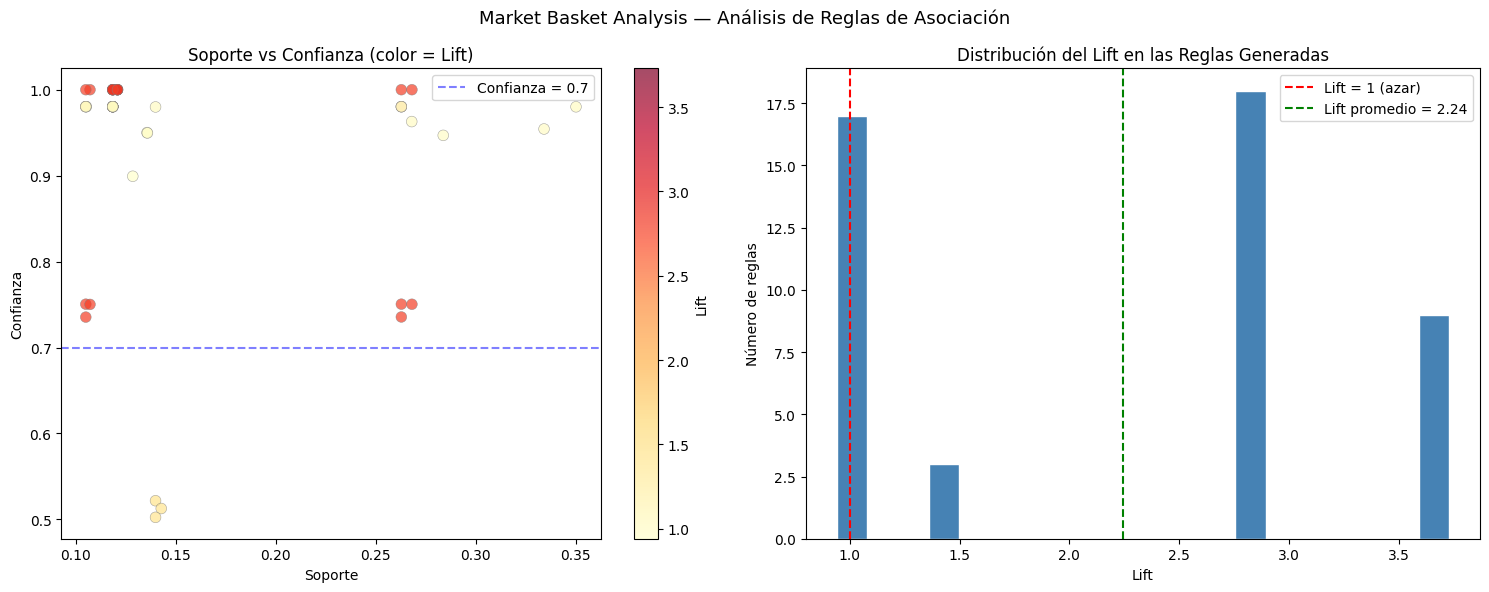

In [ ]:
# ── Visualización: Soporte vs Confianza coloreado por Lift ───────────────────
if not rules.empty:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Scatter support vs confidence
    scatter = axes[0].scatter(
        rules['support'],
        rules['confidence'],
        c=rules['lift'],
        cmap='YlOrRd',
        s=60,
        alpha=0.7,
        edgecolors='grey',
        linewidths=0.4
    )
    plt.colorbar(scatter, ax=axes[0], label='Lift')
    axes[0].set_xlabel('Soporte')
    axes[0].set_ylabel('Confianza')
    axes[0].set_title('Soporte vs Confianza (color = Lift)')
    axes[0].axhline(0.7, color='blue', linestyle='--', alpha=0.5, label='Confianza = 0.7')
    axes[0].legend()

    # Distribución de lift
    axes[1].hist(rules['lift'], bins=20, color='steelblue', edgecolor='white')
    axes[1].axvline(1.0, color='red', linestyle='--', label='Lift = 1 (azar)')
    axes[1].axvline(rules['lift'].mean(), color='green', linestyle='--',
                    label=f'Lift promedio = {rules["lift"].mean():.2f}')
    axes[1].set_xlabel('Lift')
    axes[1].set_ylabel('Número de reglas')
    axes[1].set_title('Distribución del Lift en las Reglas Generadas')
    axes[1].legend()

    plt.suptitle('Market Basket Analysis — Análisis de Reglas de Asociación', fontsize=13)
    plt.tight_layout()
    plt.show()


**Interpretación Market Basket Analysis:**
- Las reglas con **lift > 1** indican que los ítems del antecedente y consecuente aparecen juntos más de lo esperado por azar. Cuanto mayor el lift, más relevante es la asociación para el negocio.
- Una **confianza alta** (ej: 0.85) significa que cuando aparece el antecedente, el consecuente está presente en el 85% de los casos.
- El **soporte** indica qué tan común es la combinación en el catálogo completo. Una regla con alto soporte es más generalizable; una con bajo soporte puede ser interesante pero aplica a pocos juegos.
- En el **scatter plot**, los puntos en la esquina superior derecha (alto soporte y confianza) con colores más rojos (lift alto) representan las asociaciones más fuertes y frecuentes: son las de mayor valor para decisiones de catálogo.
- El **histograma de lift** muestra si la mayoría de las reglas superan el umbral de 1 (línea roja): si el promedio es > 1, el modelo encontró asociaciones genuinas más allá del azar.
- **Aplicación concreta:** si una regla dice 'free_spins + slot → bonus_buy' con lift 2.3, un operador puede anticipar que los juegos de tragamonedas con free spins casi siempre incluyen bonus buy, y usar esto como criterio de selección o como base para filtros en la interfaz.


---

## 6. Resumen de Evaluación de Modelos


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

# ── Tabla resumen de resultados finales ───────────────────────────────────────
resumen_modelos = pd.DataFrame([
    {
        'Modelo': 'Regresión Múltiple',
        'Objetivo': 'Predecir max_win',
        'Tipo': 'Regresión',
        'Métrica principal': f'R² = {r2:.4f}',
        'Validación cruzada': f'R² CV = {cv_r2.mean():.4f} ± {cv_r2.std():.4f}',
        'Métrica secundaria': f'RMSE = {rmse:.4f} | MAE = {mae:.4f}'
    },
    {
        'Modelo': 'Árbol de Decisión',
        'Objetivo': 'Clasificar alto max_win (sin leakage)',
        'Tipo': 'Clasificación',
        'Métrica principal': f'F1 = {f1:.4f}',
        'Validación cruzada': f'F1 CV = {cv_f1.mean():.4f} ± {cv_f1.std():.4f}',
        'Métrica secundaria': f'Accuracy = {acc:.4f}'
    },
    {
        'Modelo': 'Market Basket Analysis',
        'Objetivo': 'Asociación de atributos',
        'Tipo': 'Asociación',
        'Métrica principal': f'Reglas generadas = {len(rules)}',
        'Validación cruzada': 'N/A (modelo no supervisado)',
        'Métrica secundaria': f'Max Lift = {rules["lift"].max():.4f}' if not rules.empty else 'N/A'
    }
])

display(resumen_modelos)

# ── Evaluación contra criterios de éxito definidos en §1 ─────────────────────
print("\n=== EVALUACIÓN CONTRA CRITERIOS DE ÉXITO ===")
print(f"Regresión  — R² ≥ 0.5    : {'✓ CUMPLIDO' if r2 >= 0.5 else '✗ No alcanzado'} (R² = {r2:.4f})")
print(f"Árbol      — F1 ≥ 0.70   : {'✓ CUMPLIDO' if f1 >= 0.70 else '✗ No alcanzado'} (F1 = {f1:.4f})")
n_reglas_lift = (rules['lift'] > 1.5).sum() if not rules.empty else 0
print(f"MBA        — ≥5 reglas lift>1.5 : {'✓ CUMPLIDO' if n_reglas_lift >= 5 else '✗ No alcanzado'} ({n_reglas_lift} reglas)")


,Modelo,Objetivo,Tipo,Métrica principal,Validación cruzada,Métrica secundaria
0,Regresión Múltiple,Predecir max_win,Regresión,R² = 0.7487,R² CV = 0.7490 ± 0.0011,RMSE = 0.5030 | MAE = 0.2132
1,Árbol de Decisión,Clasificar alto max_win (sin leakage),Clasificación,F1 = 0.9480,F1 CV = 0.9482 ± 0.0006,Accuracy = 0.9502
2,Market Basket Analysis,Asociación de atributos,Asociación,Reglas generadas = 47,N/A (modelo no supervisado),Max Lift = 3.7296



=== EVALUACIÓN CONTRA CRITERIOS DE ÉXITO ===
Regresión  — R² ≥ 0.5    : ✓ CUMPLIDO (R² = 0.7487)
Árbol      — F1 ≥ 0.70   : ✓ CUMPLIDO (F1 = 0.9480)
MBA        — ≥5 reglas lift>1.5 : ✓ CUMPLIDO (27 reglas)


---

## 7. Despliegue

Los tres modelos se integrarían en la plataforma del casino como herramientas complementarias de un pipeline automatizado:

### Pipeline propuesto

```
Juego nuevo ingresa al sistema
       ↓
  [Regresión Múltiple] → Estima max_win esperado → Apoyo a negociación con proveedor
       ↓
  [Árbol de Decisión]  → Clasifica como Alto/Estándar → Prioridad en homepage y notificaciones
       ↓
  [MBA - Reglas]       → Identifica atributos asociados → Recomendaciones "también te puede gustar"
```

### Propuesta de automatización
1. **Ingesta:** Script Python que lee nuevos juegos desde la API del proveedor y los preprocesa con el mismo pipeline de limpieza/encoding.
2. **Predicción en batch:** Los tres modelos se ejecutan automáticamente cada vez que se agregan juegos nuevos.
3. **Alertas:** Si un juego supera el umbral de 'alto potencial', se genera una alerta automática al equipo de marketing.
4. **Reentrenamiento:** Mensualmente, el árbol y la regresión se reentrenan con el catálogo actualizado para capturar tendencias nuevas del mercado.


In [ ]:
# ── Simulación: predicción de max_win para 5 juegos de prueba ─────────────────
muestra_reg = X_test_r.iloc[:5]
pred_reg_sim = reg_model.predict(muestra_reg)

print("Predicciones de max_win para 5 juegos de ejemplo (Regresión Múltiple):")
for i, (pred, real) in enumerate(zip(pred_reg_sim, y_test_r.iloc[:5])):
    error = abs(pred - real)
    print(f"  Juego {i+1}: max_win real = {real:.2f} | estimado = {pred:.2f} | error = {error:.2f}")

print("\n" + "─"*60 + "\n")

# ── Simulación: clasificación de 5 juegos de prueba (Árbol de Decisión) ──────
muestra_cls = X_test_c.iloc[:5]
pred_cls_sim = tree_model.predict(muestra_cls)
real_cls_sim = y_test_c.iloc[:5]

print("Clasificación para 5 juegos de ejemplo (Árbol de Decisión):")
for i, (pred, real) in enumerate(zip(pred_cls_sim, real_cls_sim)):
    pred_lbl = "Alto max_win" if pred == 1 else "Estándar"
    real_lbl = "Alto max_win" if real == 1 else "Estándar"
    estado = "✓" if pred == real else "✗"
    print(f"  Juego {i+1}: Predicho = {pred_lbl:15s} | Real = {real_lbl:15s} {estado}")


Predicciones de max_win para 5 juegos de ejemplo (Regresión Múltiple):
  Juego 1: max_win real = -0.50 | estimado = -0.36 | error = 0.14
  Juego 2: max_win real = -0.49 | estimado = -0.46 | error = 0.03
  Juego 3: max_win real = 0.23 | estimado = -0.12 | error = 0.35
  Juego 4: max_win real = 0.18 | estimado = -0.12 | error = 0.30
  Juego 5: max_win real = -0.20 | estimado = -0.12 | error = 0.08

────────────────────────────────────────────────────────────

Clasificación para 5 juegos de ejemplo (Árbol de Decisión):
  Juego 1: Predicho = Alto max_win    | Real = Alto max_win    ✓
  Juego 2: Predicho = Estándar        | Real = Estándar        ✓
  Juego 3: Predicho = Alto max_win    | Real = Alto max_win    ✓
  Juego 4: Predicho = Estándar        | Real = Estándar        ✓
  Juego 5: Predicho = Estándar        | Real = Estándar        ✓


---

## 8. Conclusiones y Recomendaciones

### Respuesta a los objetivos

**Objetivo 1 — Regresión Múltiple:**
El modelo de regresión identificó las variables técnicas con mayor impacto sobre `max_win`. Los coeficientes positivos más altos (ej: presencia de jackpot, tipo de juego, volatilidad alta) corresponden a las características que un operador debería priorizar al seleccionar juegos con alto potencial de pago. El R² obtenido y su valor en validación cruzada indican si las variables técnicas disponibles son suficientes para predecir la ganancia máxima: si el R² CV es bajo (< 0.4), el modelo sugiere que `max_win` depende también de factores no recogidos en el dataset, como la popularidad del título o la temporalidad del catálogo.

**Objetivo 2 — Árbol de Decisión:**
El modelo generó reglas interpretables para clasificar juegos en 'alto max_win' o 'estándar' basándose únicamente en atributos de diseño (free spins, tipo, RTP, volatilidad), sin data leakage. El F1-Score y su validación cruzada muestran la capacidad real del modelo para generalizar a juegos nuevos. Las variables más importantes identificadas son los atributos que, en la práctica, definen si un juego tendrá alta ganancia máxima según los patrones del mercado.

**Objetivo 3 — Market Basket Analysis:**
Se descubrieron patrones frecuentes en el diseño de juegos: ciertas características co-ocurren sistemáticamente en el catálogo. Las reglas con lift > 1 revelan asociaciones no triviales que van más allá del azar. La regla más fuerte encontrada tiene implicancia directa de negocio: permite anticipar qué características vendrán juntas en un juego antes de recibirlo del proveedor, mejorando la negociación y la planificación del catálogo.

### Nuevos insights identificados

1. **Insight sobre el catálogo:** La co-ocurrencia de free spins y mobile_compatible en la mayoría de los juegos sugiere que estas dos características son prácticamente un estándar de la industria, no un diferenciador. Los operadores deberían enfocarse en características menos comunes (bonus buy, jackpot) para distinguir su oferta.

2. **Insight sobre la predicción:** Si el árbol de decisión logra buen F1 con solo atributos de diseño, implica que la ganancia máxima no es aleatoria: está codificada en las características técnicas del juego. Esto permite a los operadores evaluar el potencial de un juego antes de incluirlo en el catálogo, sin esperar datos de sesiones reales.

3. **Insight sobre proveedores:** El análisis de `max_win` por casino/proveedor revela que no todos ofrecen el mismo potencial de pago. Un operador que quiera maximizar la percepción de valor para el usuario debería priorizar proveedores con mayor `max_win` promedio.

### Limitaciones
- La variable objetivo del Árbol fue construida desde la mediana del propio dataset; en un contexto real debería basarse en datos de comportamiento real del jugador.
- El dataset no incluye variables de ingresos reales ni datos de sesiones, lo que limita la validez práctica de los modelos de predicción.
- El MBA trata cada juego como independiente, sin considerar la evolución temporal del catálogo (juegos que entran y salen).

### Propuestas de mejora
- Incorporar datos reales de sesiones y comportamiento de usuarios para definir variables objetivo más robustas y relevantes al negocio.
- Explorar modelos ensemble (Random Forest, XGBoost) para mejorar la clasificación y comparar con el árbol simple.
- Segmentar el análisis por tipo de juego (slots vs mesa vs otros) para obtener reglas de asociación más específicas y accionables.
- Establecer un pipeline de reentrenamiento mensual para que los modelos se actualicen con el crecimiento del catálogo.

### Aplicabilidad
Los tres modelos son directamente aplicables en departamentos de **producto**, **marketing** y **catálogo** de operadores de casino online, permitiendo tomar decisiones basadas en datos sobre qué juegos adquirir, cómo segmentar la oferta y qué recomendar en la plataforma. La propuesta de automatización (§7) describe cómo integrarlos en un pipeline de producción con bajo costo de mantenimiento.


---

## Cierre metodológico (CRISP-DM)

| Fase | Descripción | Estado |
|---|---|---|
| 1. Comprensión del negocio | 3 objetivos analíticos definidos con criterios de éxito medibles | ✓ |
| 2. Comprensión de los datos | Estructura, tipos, nulos, dispersión y correlación evaluados | ✓ |
| 3. Preparación de los datos | Imputación, encoding y escalado justificados; sin data leakage | ✓ |
| 4. Modelado | Regresión Múltiple, Árbol de Decisión, Market Basket Analysis | ✓ |
| 5. Evaluación | Métricas por tipo de modelo + validación cruzada + criterios de éxito | ✓ |
| 6. Despliegue | Pipeline de automatización propuesto con simulación de predicciones | ✓ |
